# Introduction to AI/ML in Microscopy

**IMC-21: Artificial Intelligence Methods for Microscopy Analysis and Knowledge Extraction**

*Session 1 (09:00–10:00) — Rama Vasudevan, Center for Nanophase Materials Sciences, ORNL*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pycroscopy/IMC21-Workshop/blob/main/notebooks/9_00_Introduction_to_AI_ML_in_Microscopy.ipynb)

---

## Introduction

Modern microscopes cna produce a very large quanitity of imaging and spectroscopic data. This hands-on session introduces  core unsupervised machine-learning workflows that exemplify some modern microscopy analysis:

1. **Image Patch Analysis**: turning a micrograph into a matrix of local observations via sliding windows
2. **Dimensionality reduction**: PCA and NMF — what the differences are and when to use each
3. **Clustering**: k-means and Gaussian mixtures for segmenting an image into structurally distinct regions
4. **Denoising** as a by-product of low-rank structure

We work on a simulated atomically resolved image so that we know the ground truth for comparisons, which is always a good practice when learning and benchmarking ML methods. The 11:00 session (Gerd) will cover loading real experimental files with `SciFiReaders`/`sidpy`, and the 13:00 session builds on today's windows-and-clustering machinery to extract *thermodynamic* knowledge from images.

##  ML in microscopy

Rough guide to the day's schedule:

| Class | Question it answers | Microscopy examples |
|---|---|---|
| **Unsupervised** | "What structure is in my data?" | PCA/NMF unmixing, clustering, local crystallography |
| **Supervised** | "Where is X in my image?" | Deep-learning atom finding, defect segmentation |
| **Generative / physics-based** | "What model produced this data?" | Statistical-distance model fitting (13:00 session) |
| **Active learning** | "Where should I measure next?" | Autonomous experiments, Bayesian optimization (afternoon) |

We will first walk through some basic analysis of imaging (and higher dimensional data) with dimensionality reduction and clustering methods in the following cells. 

In [ ]:
# --- Setup: install packages (Colab-safe). Skip if you already have them. ---
#First we will begin by installing and then importing required packages
try:
    import pycroscopy, sidpy
except ImportError:
    !pip install -q sidpy pysptools tensorly
    !pip install -q --no-deps pycroscopy
    import pycroscopy, sidpy

import numpy as np
import matplotlib.pyplot as plt
import io, contextlib, warnings
warnings.filterwarnings('ignore', module=r'sidpy.*')  
from scipy.ndimage import gaussian_filter
from sklearn.decomposition import PCA, NMF
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

import sidpy
from pycroscopy.image import ImageWindowing

print('pycroscopy', pycroscopy.__version__, '| sidpy', sidpy.__version__)
plt.rcParams.update({'figure.dpi': 100, 'image.cmap': 'afmhot'})
rng = np.random.default_rng(42)

pycroscopy 0.63.3 | sidpy 0.12.9


## 1. Simulated image: a bicrystal with vacancies

We simulate an atomically resolved image of a **bicrystal**: two grains of the same square lattice, misoriented by 12°, meeting at a vertical grain boundary. We will further add in ~2% vacancies as well as realistic imaging features, i.e., Poisson-like noise and a slowly varying background.

In HAADF-STEM the intensity of an atomic column scales roughly as $Z^{1.7}$, and each column appears as a peak with width set by the probe size. We model each atom as a 2D Gaussian and let its amplitude fluctuate slightly (static disorder / mistilt).

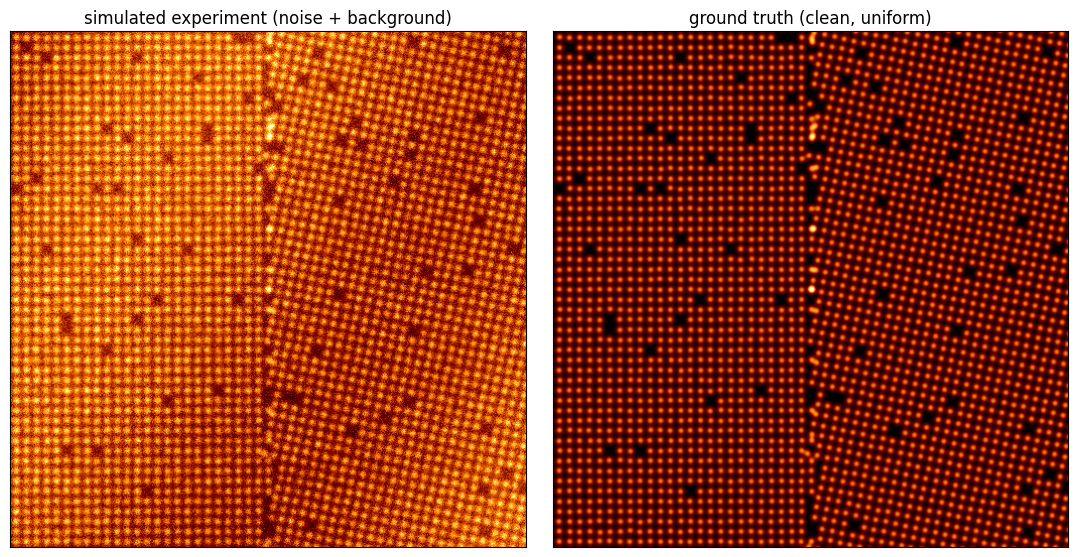

In [2]:
def make_lattice_points(a, theta_deg, extent, jitter=0.0, rng=None):
    """Square-lattice points with lattice constant a (pixels), rotated by theta, filling `extent`."""
    th = np.deg2rad(theta_deg)
    R = np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]])
    m = int(extent / a) + 4
    ij = np.mgrid[-m:m, -m:m].reshape(2, -1).T * a
    pts = ij @ R.T + extent / 2
    keep = (pts[:, 0] > -a) & (pts[:, 0] < extent + a) & (pts[:, 1] > -a) & (pts[:, 1] < extent + a)
    pts = pts[keep]
    if jitter and rng is not None:
        pts = pts + rng.normal(0, jitter, pts.shape)
    return pts

def render(pts, extent, sigma=2.6, amps=None):
    """Render atoms as Gaussians of width sigma (the 'probe size')."""
    img = np.zeros((extent, extent))
    if amps is None:
        amps = np.ones(len(pts))
    yy, xx = np.mgrid[0:extent, 0:extent]
    for (x, y), A in zip(pts, amps):     # loop is fine at this scale
        if -4*sigma < x < extent + 4*sigma and -4*sigma < y < extent + 4*sigma:
            sl = np.s_[max(0, int(y-4*sigma)):int(y+4*sigma), max(0, int(x-4*sigma)):int(x+4*sigma)]
            img[sl] += A * np.exp(-((xx[sl]-x)**2 + (yy[sl]-y)**2) / (2*sigma**2))
    return img

N = 512          # image size, pixels
a = 10           # lattice constant, pixels

pts_L = make_lattice_points(a, 0, N, jitter=0.25, rng=rng)
pts_R = make_lattice_points(a, 12, N, jitter=0.25, rng=rng)
pts_L = pts_L[pts_L[:, 0] < N/2 + rng.normal(0, 3, len(pts_L))]   # ragged boundary
pts_R = pts_R[pts_R[:, 0] >= N/2 + rng.normal(0, 3, len(pts_R))]
all_sites = np.vstack([pts_L, pts_R])

# ~2% vacancies and mild amplitude disorder
occupied = rng.random(len(all_sites)) > 0.02
vacancy_sites = all_sites[~occupied]
pts = all_sites[occupied]
amps = rng.normal(1.0, 0.08, len(pts))
print(f'{len(vacancy_sites)} vacancies out of {len(all_sites)} candidate sites ({100*len(vacancy_sites)/len(all_sites):.1f}%)')

clean = render(pts, N)
yy, xx = np.mgrid[0:N, 0:N] / N
background = 0.25 * np.sin(2*np.pi*(0.7*xx + 0.4*yy)) + 0.2*xx
image = render(pts, N, amps=amps) + background + rng.normal(0, 0.15, (N, N))

fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))
ax[0].imshow(image); ax[0].set_title('simulated experiment (noise + background)')
ax[1].imshow(clean); ax[1].set_title('ground truth (clean, uniform)')
for a_ in ax: a_.set_xticks([]); a_.set_yticks([])
plt.tight_layout()

**Observe by eye first.** It would be good to be able to extract local statistics on images like this. How can we do that?

## 2. Images as data: the sliding-window transform

An image is not yet a dataset in the ML sense. One trick we can apply is the **sliding-window transform**: extract a small patch around every (subsampled) pixel, and treat each patch as one observation — a vector in a $d$-dimensional space where $d$ = window area. An image becomes a matrix $X \in \mathbb{R}^{n_\text{windows} \times d}$, then we can use linear algebra methods to decompose it.

The important design choice is what representation we want to use:

- **Real-space windows** are sensitive to the *phase* of the lattice — two windows on the same lattice but shifted by half a unit cell look very different. Good for finding atoms/defects, but bad for comparing crystallography.
- **The magnitude of the window's FFT** discards that phase: it is invariant to translation but keeps *orientation* and *periodicity*. Each window's $|FFT|$ is a local diffraction pattern. This is good for separating phases.

We use `pycroscopy.image.ImageWindowing`, which does the windowing, optional filtering (a Hamming filter is the default), FFT, and zooming, all in one object. Window size trades off spatial resolution against reciprocal-space resolution.

In [ ]:
# wrap the image as a sidpy Dataset (the common currency of the pycroscopy ecosystem)
ds = sidpy.Dataset.from_array(image, name='bicrystal')
ds.data_type = 'image'

parms = dict(window_size_x=48, window_size_y=48,     # ~5 unit cells: enough for a sharp local FFT
             window_step_x=8, window_step_y=8,        # dense sampling for smooth maps
             mode='fft', fft_mode='abs',
             filter='hamming',                        # choose a hamming window
             zoom_factor=2)                           # keep the central (low-frequency) region
iw = ImageWindowing(parms)
with contextlib.redirect_stdout(io.StringIO()):       # we can mute some output
    fft_windows = iw.MakeWindows(ds)

# NB: ImageWindowing indexes the window grid as [x, y] (column-first);
# window *content* is ordinary row-major. We transpose maps for display to match the image.
n_wx, n_wy, wy, wx = fft_windows.shape
X_fft = np.log1p(np.abs(np.array(fft_windows))).reshape(n_wx*n_wy, -1)  # log compresses dynamic range
print(f'{n_wx} x {n_wy} window grid, each {wy} x {wx} px -> data matrix X: {X_fft.shape}')

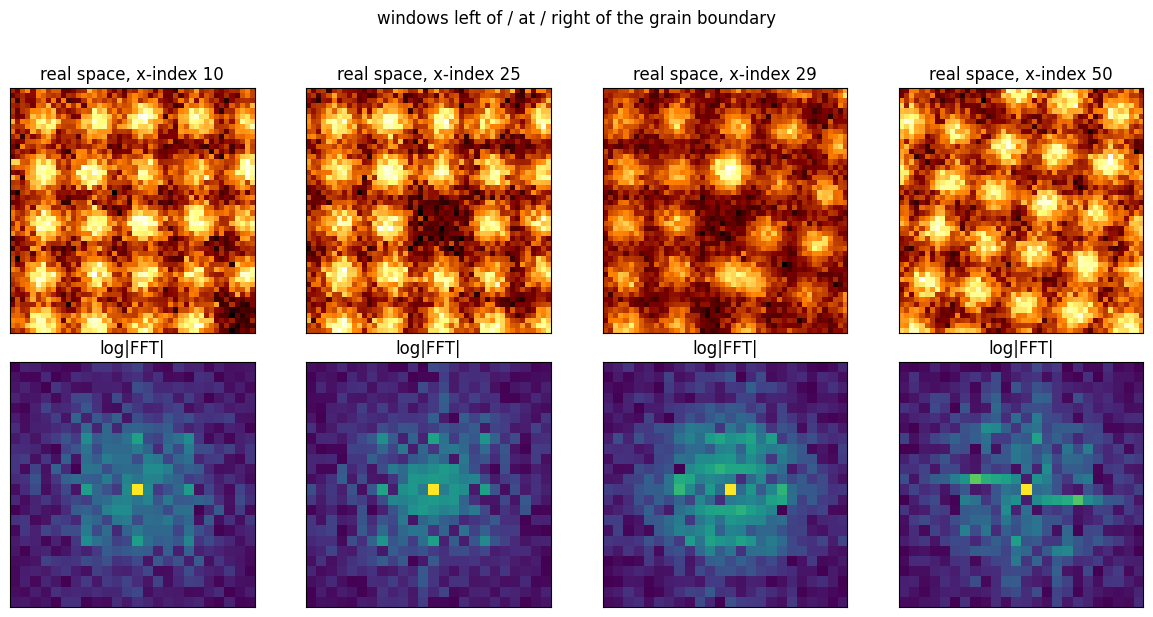

In [4]:
# also grab real-space windows (for denoising later) and show a few examples of both
parms_rs = dict(window_size_x=48, window_size_y=48, window_step_x=8, window_step_y=8, mode='image')
with contextlib.redirect_stdout(io.StringIO()):
    rs_windows = np.array(ImageWindowing(parms_rs).MakeWindows(ds))

fig, ax = plt.subplots(2, 4, figsize=(12, 6))
# window-grid index 0 walks along x: the boundary (x ~ 256 px) sits near i = 29
for k, (i, j) in enumerate([(10, 30), (25, 30), (29, 30), (50, 30)]):
    ax[0, k].imshow(rs_windows[i, j]); ax[0, k].set_title(f'real space, x-index {i}')
    ax[1, k].imshow(X_fft[i*n_wy + j].reshape(wy, wx), cmap='viridis')
    ax[1, k].set_title('log|FFT|')
for a_ in ax.ravel(): a_.set_xticks([]); a_.set_yticks([])
plt.suptitle('windows left of / at / right of the grain boundary', y=1.02)
plt.tight_layout()

Notice how the FFT windows form a local diffraction pattern: four first-order spots encode the lattice orientation. The two grains produce spot patterns rotated by 12°. Windows straddling the boundary show *both* sets of spots, i.e. they are mixtures, which motivates linear unmixing.

## 3. Linear unmixing: PCA

Principal component analysis writes every observation as a linear combination of orthogonal *components* ordered by explained variance:
$$X \approx \sum_{k=1}^{K} \; \underbrace{t_k}_{\text{abundance map}} \; \underbrace{\mathbf{p}_k^{\top}}_{\text{component (endmember)}}$$

For microscopy the payoff is twofold. First, **interpretation**: the leading components reveal the dominant modes of variation (here: the two grain orientations). Second, **compression/denoising**: uncorrelated noise spreads its variance uniformly over all components, while structure concentrates in the first few — so a truncated reconstruction keeps signal and discards noise.

The scree plot (variance vs component index) is typically the first thing we look at to determine if things are working as we expect. The linear portion fo the scree plot on the semilogy plot indicates the 'noninformative' region.

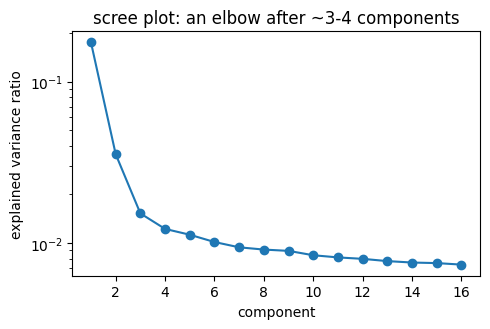

In [5]:
#Compute the PCA
pca = PCA(n_components=16, random_state=0)
scores = pca.fit_transform(X_fft - X_fft.mean(axis=0))

fig, ax = plt.subplots(figsize=(5, 3.4))
ax.semilogy(np.arange(1, 17), pca.explained_variance_ratio_, 'o-')
ax.set_xlabel('component'); ax.set_ylabel('explained variance ratio')
ax.set_title('scree plot: an elbow after ~3-4 components')
plt.tight_layout()

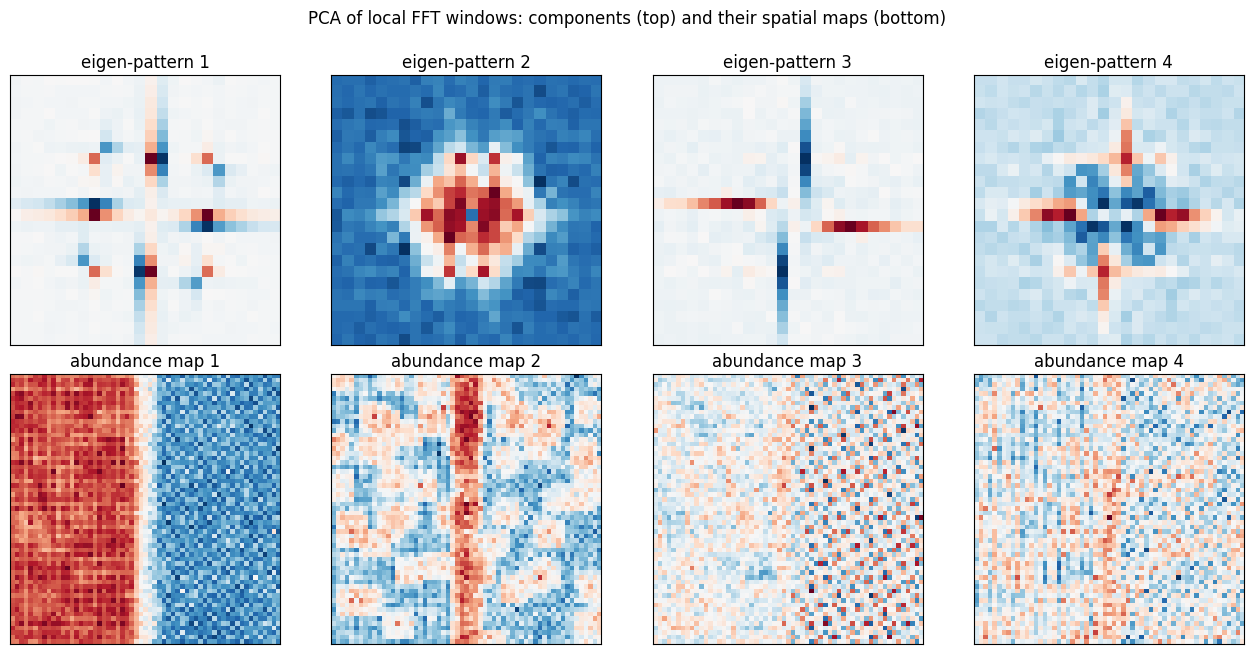

In [6]:
#Plot the components
fig, ax = plt.subplots(2, 4, figsize=(13, 6.5))
for k in range(4):
    ax[0, k].imshow(pca.components_[k].reshape(wy, wx), cmap='RdBu_r')
    ax[0, k].set_title(f'eigen-pattern {k+1}')
    ax[1, k].imshow(scores[:, k].reshape(n_wx, n_wy).T, cmap='RdBu_r')
    ax[1, k].set_title(f'abundance map {k+1}')
for a_ in ax.ravel(): a_.set_xticks([]); a_.set_yticks([])
plt.suptitle('PCA of local FFT windows: components (top) and their spatial maps (bottom)', y=1.0)
plt.tight_layout()

**Reading the result.** Because we subtracted the mean pattern first, component 1 is a *difference* pattern, i.e. it is positive at one grain's spot positions, negative at the others, and its abundance map segments the two grains almost perfectly. However, PCA is unphysical. Negative intensities in FFT are obviously impossible, which means that these components cannot be physically interpreted. This leads us towards other unmixing methods that respect the physics of the problem a bit more. So we can drop one constraint (orthogonality) in favor of another (non-negativity).

## 4. NMF: non-negative matrix factorization

NMF solves the same factorization with $t_k \ge 0$ and $\mathbf{p}_k \ge 0$. For intensity-like data (counts, FFT magnitudes, spectra) this matches the physical generative process — observed signal = non-negative mixture of non-negative sources — and typically yields *parts-based*, directly interpretable endmembers. The cost: no orthogonality, no unique ordering, and a non-convex optimization (run it a few times / fix the seed). `pycroscopy.learn.MatrixFactor` wraps several such factorizations for sidpy datasets; here we call scikit-learn directly so you can see the full process, but the pcyroscopy wrapper function is more useful in established workflows.

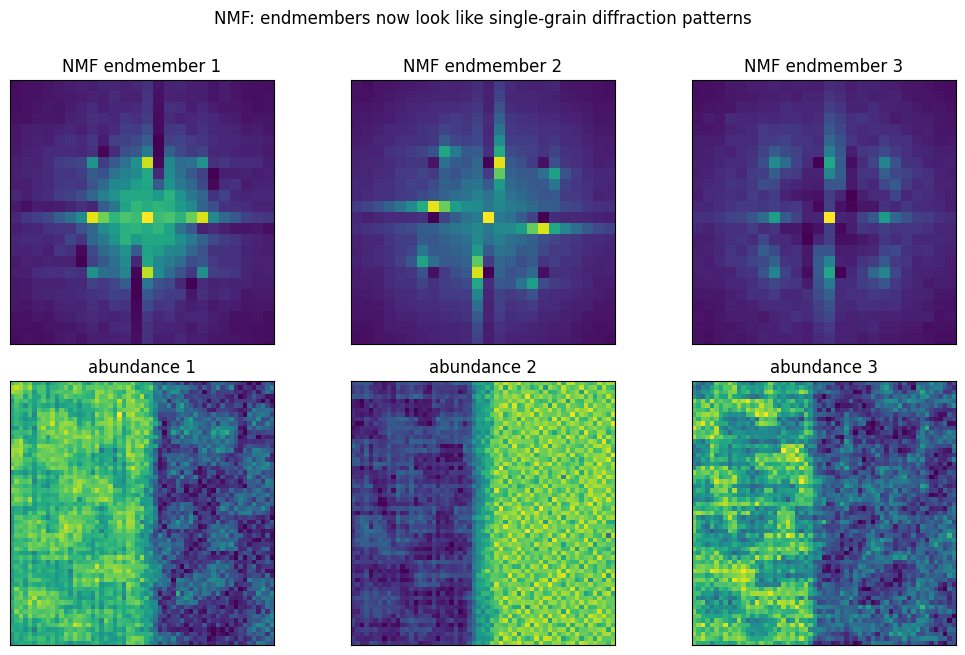

In [7]:
nmf = NMF(n_components=3, init='nndsvda', random_state=0, max_iter=400)
W = nmf.fit_transform(X_fft)          # abundances (n_windows x 3)
H = nmf.components_                   # endmember patterns (3 x d)

fig, ax = plt.subplots(2, 3, figsize=(10.5, 6.5))
for k in range(3):
    ax[0, k].imshow(H[k].reshape(wy, wx), cmap='viridis'); ax[0, k].set_title(f'NMF endmember {k+1}')
    ax[1, k].imshow(W[:, k].reshape(n_wx, n_wy).T, cmap='viridis'); ax[1, k].set_title(f'abundance {k+1}')
for a_ in ax.ravel(): a_.set_xticks([]); a_.set_yticks([])
plt.suptitle('NMF: endmembers now look like single-grain diffraction patterns', y=1.0)
plt.tight_layout()

Each NMF endmember is now recognizable as a grain's diffraction pattern (plus one component that absorbs background/boundary signal), and the abundance maps read directly as "how much of grain A is under this window". This makes intepretation much easier. Further contraints, such as sum to 1 constraints in the abundances can also be applied (e.g., N-FINDR, see the exercises). 

## 5. Clustering: from mixtures to labels

Unmixing gives fractional compositions; but sometimes we want a class, i.e. "which grain is this pixel in?" THe **k-means** algorithm partitions the windows into $k$ clusters by minimizing within-cluster variance. 

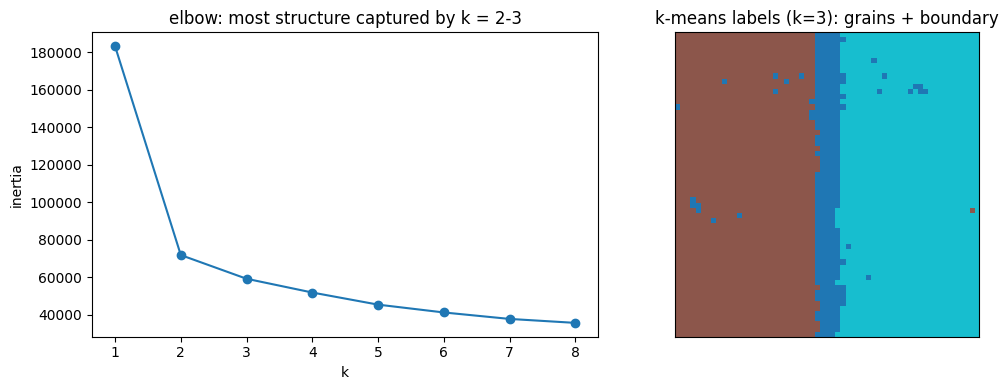

In [8]:
Xr = scores[:, :6]                     # cluster in the 6-D PCA space for speed
inertias = []
for k in range(1, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Xr)
    inertias.append(km.inertia_) #inertia is the within cluster sum of squares summed across all clusters
    
#Plot the results
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(range(1, 9), inertias, 'o-'); ax[0].set_xlabel('k'); ax[0].set_ylabel('inertia')
ax[0].set_title('elbow: most structure captured by k = 2-3')

km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(Xr)
ax[1].imshow(km.labels_.reshape(n_wx, n_wy).T, cmap='tab10', interpolation='nearest')
ax[1].set_title('k-means labels (k=3): grains + boundary')
ax[1].set_xticks([]); ax[1].set_yticks([])
plt.tight_layout()

k=2 or k=3 look like the correct number according to the inertia graph. A **Gaussian mixture model** (GMM) represents data as a sum of several gaussian distributions. You can think of GMMs as a generalization of kmeans, where we can incorproate information about the covariance. After we fit the GMM we can look at the entropy of the posterior (remember for a Gaussian this just scales with $\sigma^2$), which provides us an uncertainty map which is very useful as a tool for active learning.

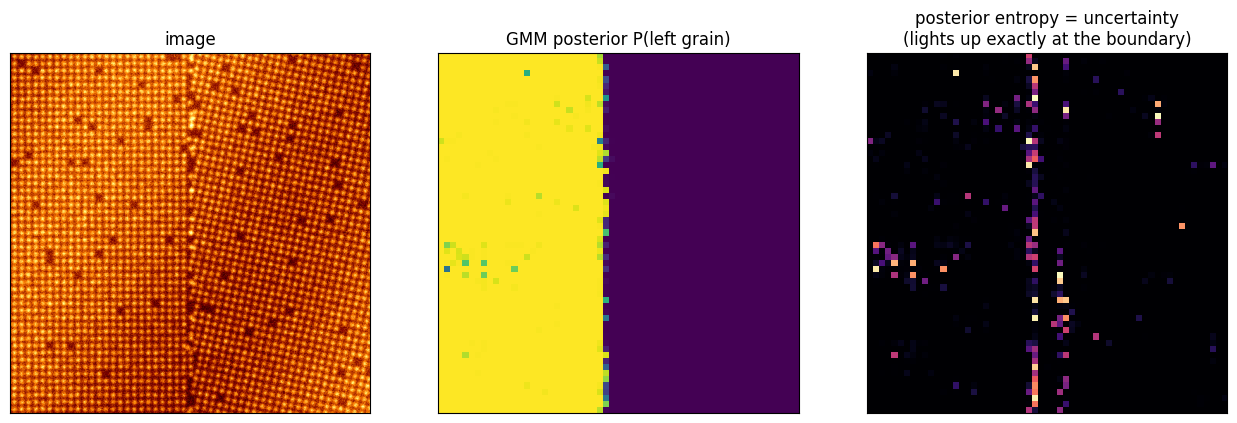

In [9]:
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=0).fit(Xr)
post = gmm.predict_proba(Xr)
entropy = -(post * np.log(post + 1e-12)).sum(axis=1)

fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
ax[0].imshow(image); ax[0].set_title('image')
left_grain_comp = post[(n_wx//4)*n_wy + n_wy//2].argmax()   # component owning a window deep in the left grain
ax[1].imshow(post[:, left_grain_comp].reshape(n_wx, n_wy).T, cmap='viridis')
ax[1].set_title('GMM posterior P(left grain)')
ax[2].imshow(entropy.reshape(n_wx, n_wy).T, cmap='magma')
ax[2].set_title('posterior entropy = uncertainty\n(lights up at the boundary)')
for a_ in ax: a_.set_xticks([]); a_.set_yticks([])
plt.tight_layout()

## 6. Denoising as a by-product of low rank

The same low-rank idea that powered interpretation also denoises. You can reconstruct images by using the matrix factorization factors to reconstruct the matrix. You lose some information but cut out the noise.

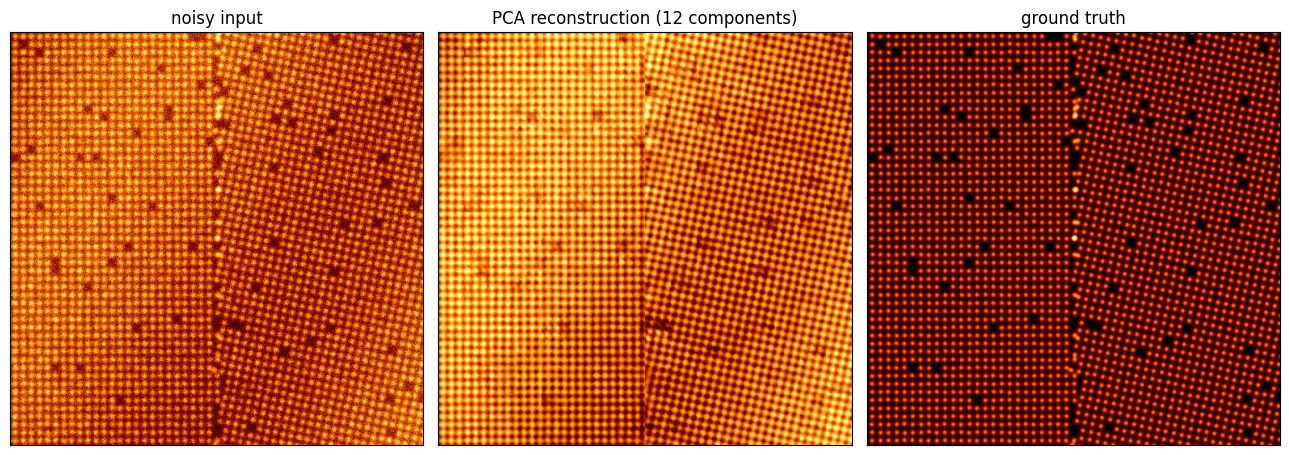

In [10]:
# non-overlapping real-space windows so we can tile the reconstruction back
step = 32
parms_dn = dict(window_size_x=step, window_size_y=step, window_step_x=step, window_step_y=step, mode='image')
with contextlib.redirect_stdout(io.StringIO()):
    w_dn = np.array(ImageWindowing(parms_dn).MakeWindows(ds))
nxw, nyw = w_dn.shape[:2]                 # grid is [x, y]
Xd = w_dn.reshape(nxw*nyw, -1)

pca_dn = PCA(n_components=12, random_state=0)
Xd_rec = pca_dn.inverse_transform(pca_dn.fit_transform(Xd - Xd.mean(0))) + Xd.mean(0)
# tile back: block (i, j) of the grid is the image patch at rows j*step, cols i*step
den = Xd_rec.reshape(nxw, nyw, step, step).transpose(1, 2, 0, 3).reshape(nyw*step, nxw*step)

fig, ax = plt.subplots(1, 3, figsize=(13, 4.5))
ax[0].imshow(image[:nyw*step, :nxw*step]); ax[0].set_title('noisy input')
ax[1].imshow(den); ax[1].set_title('PCA reconstruction (12 components)')
ax[2].imshow(clean[:nyw*step, :nxw*step]); ax[2].set_title('ground truth')
for a_ in ax: a_.set_xticks([]); a_.set_yticks([])
plt.tight_layout()

## Exercises

1. **Window size.** Re-run Section 2-3 with 24-pixel and 96-pixel windows. How does the grain-boundary sharpness of the abundance maps change? Why? (Think Fourier uncertainty: spatial vs reciprocal resolution.)
2. **Real vs reciprocal space.** Cluster the *real-space* windows instead of the FFT windows with k=3. Explain what the clusters latch onto, and why they fail to separate the grains.
3. **Choosing k honestly.** Compute silhouette scores (`sklearn.metrics.silhouette_score`) for k = 2..8 and compare with the elbow. Do they agree?
4. **A third phase.** Modify the simulation to give the right-hand grain a 20% larger lattice constant (a different "phase"). Which PCA component picks it up? Does k-means need a larger k?
5. **Vacancy hunting (harder).** The simulation contains ~2% vacancies. Design a windows-based pipeline that localizes them. (Hint: use small real-space windows centered on lattice sites, then look at distances to the cluster centroid and pay attention to the outliers)
6. **Interpretability of N-FINDR** Instead of using NMF, use N-FINDR, which is available in pycroscopy.learn.MatrixFactor and compare the results for 2,3, and 4 components. Does it provide superior results?
7. **ADVANCED** If you are feeling so inclined, see if you can find the atoms present in the image, and then run the stats through the local crystallography stats package in pycroscopy to compute local PCA and K-Means on the local neighborhoods to try to find the vacancies and the grain boundary through another method.

In [ ]:
# Completed Exercise 5: vacancy hunting with small real-space windows
#
# Idea:
# 1. Use the known lattice-site candidates from the simulation.
# 2. Extract dense, small real-space windows with pycroscopy ImageWindowing.
# 3. Assign one nearest extracted window to each lattice site.
# 4. Fit k-means to the common occupied-site windows.
# 5. Vacancies are rare, so identify the site windows with the largest distance
#    to their assigned cluster centroid.

from scipy.spatial import cKDTree

small_window = 12     # just over one unit cell; local enough to see whether the central peak is missing
small_step = 2        # dense enough that each candidate site has a nearby pycroscopy window center
expected_vacancy_fraction = 0.02

parms_vac = dict(window_size_x=small_window, window_size_y=small_window,
                 window_step_x=small_step, window_step_y=small_step,
                 mode='image')
with contextlib.redirect_stdout(io.StringIO()):
    site_windows_dense = np.array(ImageWindowing(parms_vac).MakeWindows(ds))

n_xw, n_yw, wh, ww = site_windows_dense.shape
half = small_window / 2
window_centers = np.array([(half + ix*small_step, half + iy*small_step)
                           for ix in range(n_xw) for iy in range(n_yw)])
flat_windows = site_windows_dense.reshape(n_xw*n_yw, wh, ww)

# Keep only expected lattice sites whose centers fall inside the valid window grid.
candidate_sites = all_sites.copy() if 'all_sites' in globals() else np.vstack([pts_L, pts_R])
valid = ((candidate_sites[:, 0] >= window_centers[:, 0].min()) &
         (candidate_sites[:, 0] <= window_centers[:, 0].max()) &
         (candidate_sites[:, 1] >= window_centers[:, 1].min()) &
         (candidate_sites[:, 1] <= window_centers[:, 1].max()))
candidate_sites = candidate_sites[valid]

_, nearest_window = cKDTree(window_centers).query(candidate_sites, k=1)
site_windows = flat_windows[nearest_window]

# For vacancy detection, do not normalize each patch independently; absolute intensity matters.
X_site = site_windows.reshape(len(site_windows), -1).astype(float)
center_pixel = site_windows[:, wh//2, ww//2]
patch_summary = np.c_[X_site.mean(axis=1), X_site.std(axis=1), X_site.max(axis=1), center_pixel]
X_site = np.c_[X_site, patch_summary]
X_site = (X_site - X_site.mean(axis=0)) / (X_site.std(axis=0) + 1e-9)

km_sites = KMeans(n_clusters=2, n_init=30, random_state=0).fit(X_site)
centroid_distance = km_sites.transform(X_site).min(axis=1)

n_expected = max(1, int(round(expected_vacancy_fraction * len(candidate_sites))))
outlier_order = np.argsort(centroid_distance)[::-1]
predicted_vacancy_sites = candidate_sites[outlier_order[:n_expected]]

# Ground truth is available because this is a simulation.
truth_sites = vacancy_sites if 'vacancy_sites' in globals() else np.empty((0, 2))
if len(truth_sites):
    truth_valid = ((truth_sites[:, 0] >= window_centers[:, 0].min()) &
                   (truth_sites[:, 0] <= window_centers[:, 0].max()) &
                   (truth_sites[:, 1] >= window_centers[:, 1].min()) &
                   (truth_sites[:, 1] <= window_centers[:, 1].max()))
    truth_sites = truth_sites[truth_valid]

if len(truth_sites):
    truth_tree = cKDTree(truth_sites)
    pred_to_truth_dist, _ = truth_tree.query(predicted_vacancy_sites, k=1)
    truth_tree_all = cKDTree(candidate_sites)
    _, truth_candidate_idx = truth_tree_all.query(truth_sites, k=1)
    true_candidate_mask = np.zeros(len(candidate_sites), dtype=bool)
    true_candidate_mask[truth_candidate_idx] = True
    predicted_mask = np.zeros(len(candidate_sites), dtype=bool)
    predicted_mask[outlier_order[:n_expected]] = True
    tp = int(np.logical_and(predicted_mask, true_candidate_mask).sum())
    fp = int(np.logical_and(predicted_mask, ~true_candidate_mask).sum())
    fn = int(np.logical_and(~predicted_mask, true_candidate_mask).sum())
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    print(f'True vacancies in valid field: {true_candidate_mask.sum()}')
    print(f'Predicted vacancies: {predicted_mask.sum()}')
    print(f'Precision = {precision:.2f}, recall = {recall:.2f}')
    print(f'Median predicted-to-true distance = {np.median(pred_to_truth_dist):.2f} px')
else:
    print('No ground-truth vacancy sites found; displaying the top outliers only.')

fig, ax = plt.subplots(1, 4, figsize=(15, 4.2))
ax[0].imshow(image)
ax[0].set_title('simulated image')
ax[1].imshow(clean)
ax[1].set_title('clean occupied columns')

# Put centroid distances back on the image as a sparse map at candidate-site positions.
sc = ax[2].scatter(candidate_sites[:, 0], candidate_sites[:, 1], c=centroid_distance,
                   s=7, cmap='magma')
ax[2].imshow(image, alpha=0.25)
ax[2].set_title('distance to nearest centroid')
plt.colorbar(sc, ax=ax[2], fraction=0.046, pad=0.04)

ax[3].imshow(image)
if len(truth_sites):
    ax[3].scatter(truth_sites[:, 0], truth_sites[:, 1], s=40, facecolors='none',
                  edgecolors='lime', linewidths=1.4, label='true vacancy')
ax[3].scatter(predicted_vacancy_sites[:, 0], predicted_vacancy_sites[:, 1],
              s=28, c='red', marker='x', label='window outlier')
ax[3].set_title('localized vacancy candidates')
ax[3].legend(loc='upper right', fontsize=8)
for a_ in ax:
    a_.set_xticks([])
    a_.set_yticks([])
plt.tight_layout()

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(centroid_distance, bins=60, color='0.35')
threshold = centroid_distance[outlier_order[n_expected-1]]
ax.axvline(threshold, color='tab:red', ls='--', label=f'top {expected_vacancy_fraction:.0%} threshold')
ax.set_xlabel('distance to assigned k-means centroid')
ax.set_ylabel('number of lattice-site windows')
ax.set_title('vacancies live in the high-distance tail')
ax.legend()
plt.tight_layout()
